# Treinamento - Rede Neural

## Objetivo

Treinar um modelo de Rede Neural para prever a probabilidade de abandono do tratamento de tuberculose (LTFU).

## Estratégia de Avaliação

- **Rodada 1:** treino -> teste1 (validação interna)
- **Rodada 2:** treino + teste1 -> teste2 (validação externa)

## Métricas Utilizadas

- Recall
- Precisão
- F1-score
- Acurácia
- ROC-AUC

**Recall** foi considerado a principal métrica do projeto, pois o objetivo é identificar o maior número possível de pacientes com risco de abandono.

## Tratamento do Desbalanceamento

- Class Weights
- Sample Weights para pacientes reingressos após abandono

## Explicabilidade

Foi utilizada a técnica **Permutation Importance** para identificar as variáveis mais importantes para as previsões do modelo.

In [21]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers, regularizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, recall_score, classification_report, precision_score,
    roc_auc_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
#Carregar os dados

BASE = '/content/drive/MyDrive/'

PASTA_RN = BASE + 'Graficos_RN/'
os.makedirs(PASTA_RN, exist_ok=True)

X_train = pd.read_csv(BASE + 'X_train_proc.csv')
X_test1 = pd.read_csv(BASE + 'X_test1_proc.csv')
X_test2 = pd.read_csv(BASE + 'X_test2_proc.csv')

y_train = pd.read_csv(BASE + 'y_train.csv').squeeze()
y_test1 = pd.read_csv(BASE + 'y_test1.csv').squeeze()
y_test2 = pd.read_csv(BASE + 'y_test2.csv').squeeze()

X_train2 = pd.concat([X_train, X_test1], ignore_index=True)
y_train2 = pd.concat([y_train, y_test1], ignore_index=True)

X_train_np = X_train.values.astype('float32')
X_test1_np = X_test1.values.astype('float32')
X_test2_np = X_test2.values.astype('float32')
X_train2_np = X_train2.values.astype('float32')

y_train_np = y_train.values.astype('int32')
y_test1_np = y_test1.values.astype('int32')
y_test2_np = y_test2.values.astype('int32')
y_train2_np = y_train2.values.astype('int32')

print(f'X_train : {X_train_np.shape}')
print(f'X_test1 : {X_test1_np.shape}')
print(f'X_train2: {X_train2_np.shape}')
print(f'X_test2 : {X_test2_np.shape}')

print(
    f'\nTaxa abandono - treino: {y_train_np.mean()*100:.1f}% | '
    f'teste1: {y_test1_np.mean()*100:.1f}% | '
    f'teste2: {y_test2_np.mean()*100:.1f}%'
)

X_train : (562632, 25)
X_test1 : (631, 25)
X_train2: (563263, 25)
X_test2 : (631, 25)

Taxa abandono - treino: 19.4% | teste1: 43.9% | teste2: 69.4%


In [23]:
# Class weights

pesos = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
pesos_dict = dict(enumerate(pesos))
print(f'Class weights Rodada 1: {pesos_dict}')

# Sample weights: reingressos com peso 3x
# TRATAMENTO=3 (reingresso) após OrdinalEncoder vira índice 2.0
col_trat = X_train.columns.get_loc('TRATAMENTO')

def calcular_sample_weight(X_np, y_np, pesos_dict, col_trat, peso_reing=3.0):
    sw = np.where(y_np == 1, pesos_dict[1], pesos_dict[0]).astype('float32')
    mask_reing = (X_np[:, col_trat] == 2.0)
    sw[mask_reing] *= peso_reing
    n_reing = mask_reing.sum()
    print(f'  Reingressos: {n_reing} ({n_reing/len(X_np)*100:.1f}%) com peso {peso_reing}x extra')
    return sw

print('\nSample weights - Rodada 1:')
sw_train = calcular_sample_weight(X_train_np, y_train_np, pesos_dict, col_trat)

pesos2 = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train2_np),
    y=y_train2_np
)

pesos2_dict = dict(enumerate(pesos2))
print(f'\nClass weights Rodada 2: {pesos2_dict}')

print('Sample weights - Rodada 2:')
col_trat2 = X_train2.columns.get_loc('TRATAMENTO')
sw_train2 = calcular_sample_weight(X_train2_np, y_train2_np, pesos2_dict, col_trat2)

Class weights Rodada 1: {0: np.float64(0.6204888635972632), 1: np.float64(2.574880553572409)}

Sample weights - Rodada 1:
  Reingressos: 58090 (10.3%) com peso 3.0x extra

Class weights Rodada 2: {0: np.float64(0.6207001049077429), 1: np.float64(2.5712492353762864)}
Sample weights - Rodada 2:
  Reingressos: 58319 (10.4%) com peso 3.0x extra


In [24]:
# Função de Avaliação

def avaliar(nome, y_true, y_pred, y_prob):
    print(f'\n{nome}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Não abandona (0)', 'Abandona (1)']))
    auc = roc_auc_score(y_true, y_prob)
    print(f'ROC-AUC: {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0],
        display_labels=['Não abandona', 'Abandona'],
        colorbar=False
    )
    axes[0].set_title(f'Matriz de Confusão - {nome}')
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
    axes[1].set_title(f'Curva ROC - {nome} (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'--', color='gray')
    plt.tight_layout()
    plt.savefig(
        PASTA_RN + f'{nome}.png',
        dpi=300,
        bbox_inches='tight'
)

    plt.show()
    return auc

def plotar_curvas(historico, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(historico.history['loss'], label='treino')
    axes[0].plot(historico.history['val_loss'], label='validação')
    axes[0].set_title(f'Loss - {titulo}')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(historico.history['auc'], label='treino')
    axes[1].plot(historico.history['val_auc'], label='validação')
    axes[1].set_title(f'AUC - {titulo}')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(
        PASTA_RN + f'{titulo}.png',
        dpi=300,
        bbox_inches='tight'
)
    plt.show()
    melhor = max(historico.history['val_auc'])
    epoca  = np.argmax(historico.history['val_auc']) + 1
    print(f'Melhor val_auc: {melhor:.4f} (época {epoca})')

print('Funções definidas!')

Funções definidas!


In [25]:
# Definição do modelo

def criar_modelo(n_features):
    modelo = keras.Sequential([
        layers.Input(shape=(n_features,)),

        # Camada 1
        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Camada 2
        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Camada 3
        layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.1),

        # Camada 4
        layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # Saída
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
           keras.metrics.AUC(name='auc'),
           keras.metrics.Recall(name='recall'),
           keras.metrics.BinaryAccuracy(name='accuracy')
           ])
    return modelo

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=8,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.1,
    patience=3,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

print('Arquitetura definida!')
criar_modelo(X_train_np.shape[1]).summary()

Arquitetura definida!


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,841 (202.50 KB)

 Trainable params: 50,881 (198.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.6471 - auc: 0.7041 - loss: 0.9476 - recall: 0.6530 - val_accuracy: 0.5876 - val_auc: 0.7215 - val_loss: 0.7471 - val_recall: 0.7369 - learning_rate: 0.0010
Epoch 2/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.6856 - auc: 0.7249 - loss: 0.8034 - recall: 0.6382 - val_accuracy: 0.6711 - val_auc: 0.7168 - val_loss: 0.6595 - val_recall: 0.6200 - learning_rate: 0.0010
Epoch 3/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.6856 - auc: 0.7272 - loss: 0.7867 - recall: 0.6442 - val_accuracy: 0.6829 - val_auc: 0.7378 - val_loss: 0.6445 - val_recall: 0.6540 - learning_rate: 0.0010
Epoch 4/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.6856 - auc: 0.7271 - loss: 0.7851 - recall: 0.6427 - val_accuracy: 0.7243 - val_auc: 0.7410 - val_loss: 0.5950 - val_recall: 0.5957 - learning_rate: 0.0010
Epoch 5/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.6878 - auc: 0.7266 - loss: 0.78

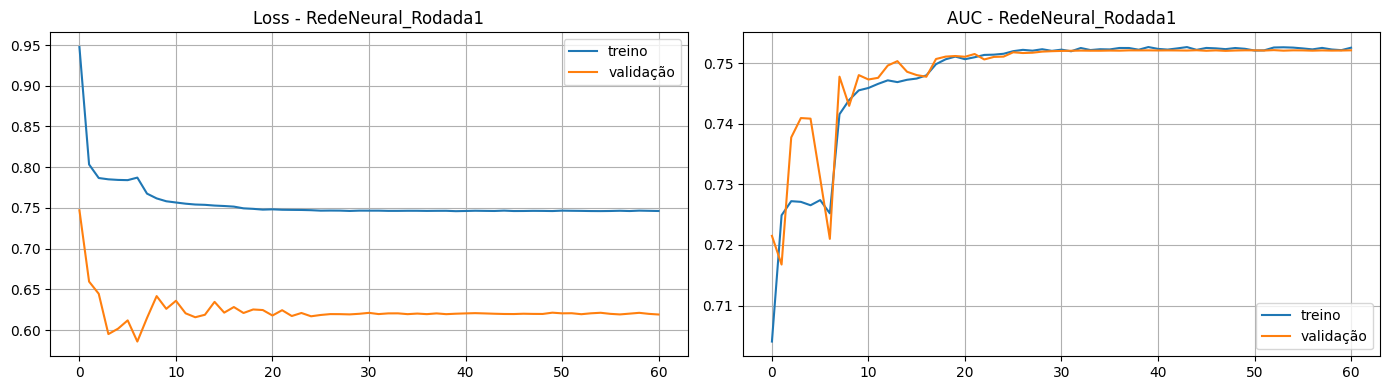

Melhor val_auc: 0.7522 (época 53)


In [26]:
# RODADA 1: treino -> teste1

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train_np,
    y_train_np,
    sw_train,
    test_size=0.1,
    stratify=y_train_np,
    random_state=42
)

modelo_RN = criar_modelo(X_train_np.shape[1])

historico = modelo_RN.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    sample_weight=sw_tr,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr]
)

plotar_curvas(historico, 'RedeNeural_Rodada1')


In [27]:
prob_test1 = modelo_RN.predict(X_test1_np, verbose=0).flatten()

In [35]:
print('Comparativo dos thresholds candidatos - Teste1')
print('-'*60)
print(f'{"Threshold":<12} {"Recall":<10} {"Precisão":<12} {"F1":<10} {"Acurácia"}')
print('-'*60)

resultados_threshold = []

for t in [0.35, 0.40, 0.50]:
    pred = (prob_test1 >= t).astype(int)

    recall = recall_score(y_test1_np, pred)
    precisao = precision_score(y_test1_np, pred)
    f1 = f1_score(y_test1_np, pred)
    acuracia = accuracy_score(y_test1_np, pred)

    resultados_threshold.append({
        'Threshold': t,
        'Recall': recall,
        'Precisão': precisao,
        'F1': f1,
        'Acurácia': acuracia
    })

    print(
        f't={t:.2f}       '
        f'{recall:.4f}    '
        f'{precisao:.4f}        '
        f'{f1:.4f}    '
        f'{acuracia:.4f}'
    )

print('-'*60)

df_threshold = pd.DataFrame(resultados_threshold)

# salvar imagem da tabela
plt.figure(figsize=(8, 2.5))
plt.axis('off')

tabela = plt.table(
    cellText=np.round(df_threshold.values, 4),
    colLabels=df_threshold.columns,
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

plt.title('Comparação dos Thresholds Avaliados - Rede Neural', pad=15)

plt.savefig(
    '/content/drive/MyDrive/Graficos_RN/tabela_thresholds_RN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()

THRESHOLD_FINAL = 0.40

print('\nInterpretação:')
print('  t=0.35 → Recall extremamente alto, porém com muitos falsos positivos.')
print('  t=0.40 → Threshold escolhido por priorizar Recall mantendo desempenho adequado.')
print('  t=0.50 → Threshold padrão, com menor Recall.')
print(f'\n>>> Threshold final selecionado: {THRESHOLD_FINAL:.2f}')



Comparativo dos thresholds candidatos - Teste1
------------------------------------------------------------
Threshold    Recall     Precisão     F1         Acurácia
------------------------------------------------------------
t=0.35       0.9711    0.5056        0.6650    0.5705
t=0.40       0.9386    0.5462        0.6906    0.6307
t=0.50       0.8484    0.6152        0.7132    0.7005
------------------------------------------------------------

Interpretação:
  t=0.35 → Recall extremamente alto, porém com muitos falsos positivos.
  t=0.40 → Threshold escolhido por priorizar Recall mantendo desempenho adequado.
  t=0.50 → Threshold padrão, com menor Recall.

>>> Threshold final selecionado: 0.40



RedeNeural_Teste1
                  precision    recall  f1-score   support

Não abandona (0)       0.89      0.39      0.54       354
    Abandona (1)       0.55      0.94      0.69       277

        accuracy                           0.63       631
       macro avg       0.72      0.66      0.62       631
    weighted avg       0.74      0.63      0.61       631

ROC-AUC: 0.8032


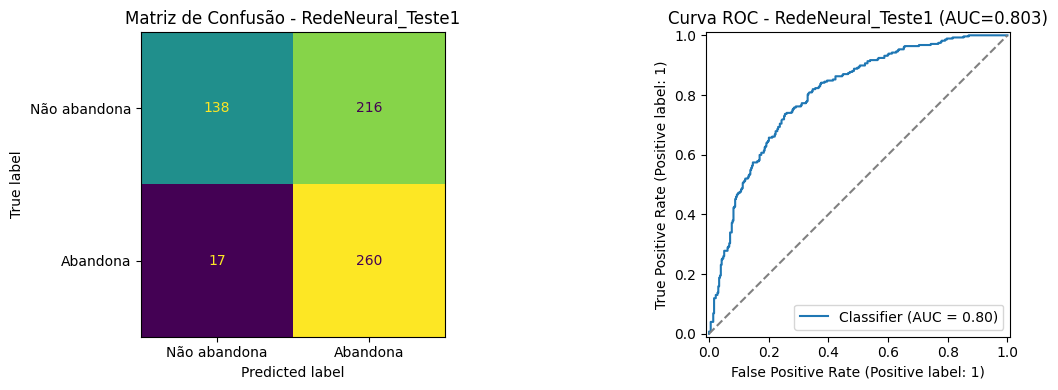

In [29]:
pred_test1_final = (prob_test1 >= THRESHOLD_FINAL).astype(int)
auc1_final = avaliar(
    'RedeNeural_Teste1',
    y_test1_np,
    pred_test1_final,
    prob_test1
)

Epoch 1/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.6590 - auc: 0.7051 - loss: 0.9301 - recall: 0.6378 - val_accuracy: 0.7652 - val_auc: 0.7342 - val_loss: 0.6399 - val_recall: 0.4964 - learning_rate: 0.0010
Epoch 2/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 35s 36ms/step - accuracy: 0.6991 - auc: 0.7268 - loss: 0.7990 - recall: 0.6248 - val_accuracy: 0.7166 - val_auc: 0.7389 - val_loss: 0.6478 - val_recall: 0.6154 - learning_rate: 0.0010
Epoch 3/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - accuracy: 0.7074 - auc: 0.7263 - loss: 0.7860 - recall: 0.6156 - val_accuracy: 0.7010 - val_auc: 0.7376 - val_loss: 0.6541 - val_recall: 0.6427 - learning_rate: 0.0010
Epoch 4/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.7053 - auc: 0.7278 - loss: 0.7826 - recall: 0.6176 - val_accuracy: 0.7020 - val_auc: 0.7388 - val_loss: 0.6738 - val_recall: 0.6298 - learning_rate: 0.0010
Epoch 5/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7065 - auc: 0.7276 - loss: 0.781

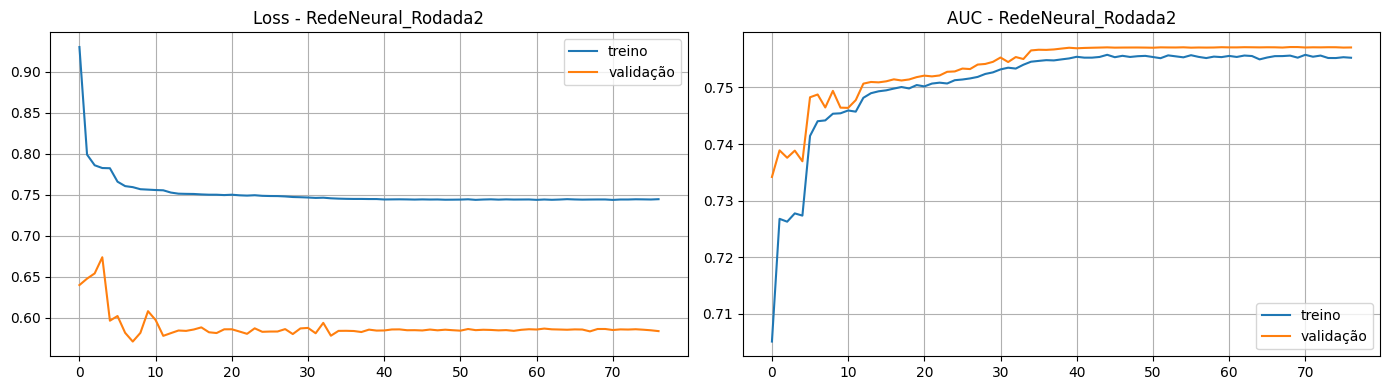

Melhor val_auc: 0.7571 (época 69)


In [30]:
# RODADA 2: treino + teste1 -> teste2

X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train2_np,
    y_train2_np,
    sw_train2,
    test_size=0.1,
    stratify=y_train2_np,
    random_state=42
)

modelo_RN2 = criar_modelo(X_train2_np.shape[1])

early_stop2 = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=8,
    restore_best_weights=True,
    mode='max'
)

reduce_lr2 = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.1,
    patience=3,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

historico2 = modelo_RN2.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    sample_weight=sw_tr,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

plotar_curvas(historico2, 'RedeNeural_Rodada2')


RedeNeural_Teste2
                  precision    recall  f1-score   support

Não abandona (0)       0.72      0.37      0.49       193
    Abandona (1)       0.77      0.94      0.85       438

        accuracy                           0.76       631
       macro avg       0.74      0.65      0.67       631
    weighted avg       0.75      0.76      0.74       631

ROC-AUC: 0.7806


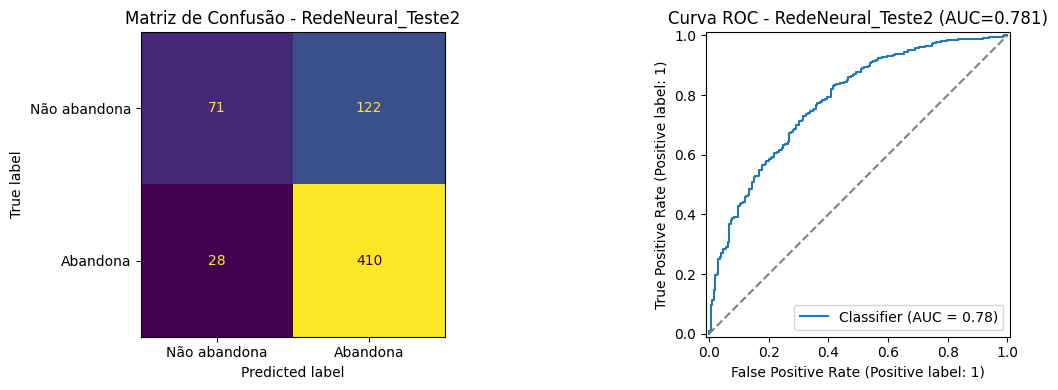

In [31]:
prob_test2 = modelo_RN2.predict(X_test2_np, verbose=0).flatten()
pred_test2_final = (prob_test2 >= THRESHOLD_FINAL).astype(int)
auc2_final = avaliar(
    'RedeNeural_Teste2',
    y_test2_np,
    pred_test2_final,
    prob_test2
)

Calculando Permutation Importance...
Concluído!


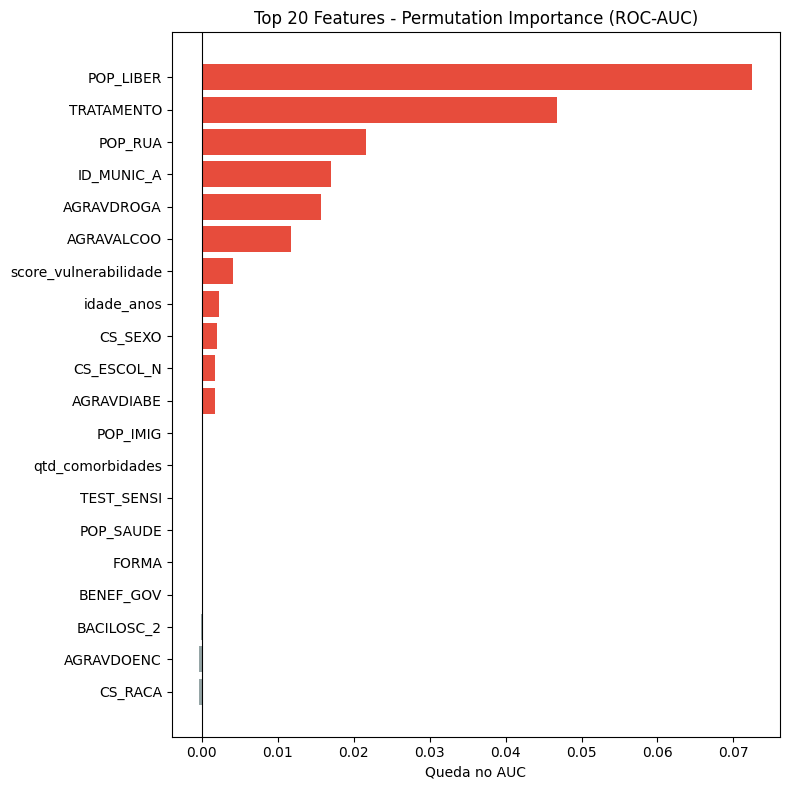


Top 10 features:
              feature  importancia
            POP_LIBER     0.072490
           TRATAMENTO     0.046825
              POP_RUA     0.021583
           ID_MUNIC_A     0.017050
           AGRAVDROGA     0.015750
           AGRAVALCOO     0.011805
score_vulnerabilidade     0.004073
           idade_anos     0.002330
              CS_SEXO     0.001977
           CS_ESCOL_N     0.001791


In [32]:
# Explicabilidade - Permutation Importance

class KerasWrapper:
    def __init__(self, model):
        self.model = model
        self._estimator_type = 'classifier'

    def fit(self, X, y):
        return self

    def predict(self, X):
        return self.model.predict(X, verbose=0)

    def score(self, X, y):
        preds = self.predict(X)
        return roc_auc_score(y, preds)

sample_size = min(631, len(X_test2_np))
idx = np.random.choice(len(X_test2_np), sample_size, replace=False)
X_sample = X_test2_np[idx]
y_sample = y_test2_np[idx]

print('Calculando Permutation Importance...')
result = permutation_importance(
    KerasWrapper(modelo_RN2),
    X_sample, y_sample,
    n_repeats=10,
    random_state=42,
    scoring=None
)
print('Concluído!')

df_imp = pd.DataFrame({
    'feature':     X_test2.columns.tolist(),
    'importancia': result.importances_mean
})
df_imp = df_imp.sort_values('importancia', ascending=False).reset_index(drop=True)

top20 = df_imp.head(20)
plt.figure(figsize=(8, 8))
plt.barh(top20['feature'][::-1], top20['importancia'][::-1],
         color=['#e74c3c' if v > 0 else '#95a5a6' for v in top20['importancia'][::-1]])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Permutation Importance (ROC-AUC)')
plt.xlabel('Queda no AUC')
plt.tight_layout()
plt.savefig(
    PASTA_RN + 'permutation_RN.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('\nTop 10 features:')
print(df_imp.head(10).to_string(index=False))
df_imp.to_csv(
    'permutation_importance.csv',
    index=False
)

In [39]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def resumo_metricas(nome, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
    'Modelo': nome,
    'Acurácia': accuracy_score(y_true, y_pred),
    'Precisão': precision_score(y_true, y_pred),
    'Recall': recall_score(y_true, y_pred),
    'F1': f1_score(y_true, y_pred),
    'ROC-AUC': roc_auc_score(y_true, y_prob)
}

pd.options.display.float_format = '{:.4f}'.format
resultados = pd.DataFrame([
    resumo_metricas('Rodada 1 - Teste1', y_test1_np, prob_test1, THRESHOLD_FINAL),
    resumo_metricas('Rodada 2 - Teste2', y_test2_np, prob_test2, THRESHOLD_FINAL),
])

print('Resultados - Rede Neural')
print(resultados.to_string(index=False))
resultados_img = resultados.copy()


for col in ['Acurácia', 'Precisão', 'Recall', 'F1', 'ROC-AUC']:
    resultados_img[col] = resultados_img[col].map(lambda x: f'{x:.4f}')

plt.figure(figsize=(10, 2.5))
plt.axis('off')

tabela = plt.table(
    cellText=resultados_img.values,
    colLabels=resultados_img.columns,
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

plt.title(
    'Resultados Finais - Rede Neural',
    pad=15
)

plt.savefig(
    '/content/drive/MyDrive/Graficos_RN/resultados_rede_neural.png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()

Resultados - Rede Neural
           Modelo  Acurácia  Precisão  Recall     F1  ROC-AUC
Rodada 1 - Teste1    0.6307    0.5462  0.9386 0.6906   0.8032
Rodada 2 - Teste2    0.7623    0.7707  0.9361 0.8454   0.7806


In [34]:
#Salvar modelos

modelo_RN2.save('/content/drive/MyDrive/modelo_RN.keras')
joblib.dump(top20, '/content/drive/MyDrive/top_features_RN.pkl')
print('modelo_RN.keras salvo!')

modelo_RN.keras salvo!
